# 서포트벡터머신(SVM)의

# SVC(Support Vector Machine Classifier) 실습


In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

cancer = load_breast_cancer()
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)
X_train, X_test, y_train, y_test = train_test_split(
    data_scaled, cancer.target, test_size=0.3, random_state=0
)

In [2]:
svc = SVC(probability=True)
svc.fit(X_train, y_train)
pred = svc.predict(X_test)
pred_proba = svc.predict_proba(X_test)[:, 1]
acc = accuracy_score(y_test, pred)
auc = roc_auc_score(y_test, pred_proba)
print(f"accuracy: {acc:.3f}, roc_auc:{auc:.3f}")

accuracy: 0.977, roc_auc:0.998


c:\Users\rlawjdgns213\Documents\GitHub\Samsung_Heavy_Industry_AI_Specialist_Education\데이터분석_Advanced\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


# Invistico_Airline 데이터 실습


In [2]:
# 파이썬 데이터 전처리 라이브러리
import pandas as pd

airline = pd.read_csv("data/Invistico_Airline.csv")
airline.head(5)

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0


[데이터 컬럼 설명]

- satisfaction : 만족도
- Gender : 성별
- Customer Type : 고객 유형
- Age : 나이
- Type of Travel : 여행 유형
- Class : 좌석 등급
- Flight Distance : 비행거리
- Seat comfort : 좌석의 편안함, 0 ~ 5점
- Departure/Arrival time convenient : 편리한 출발/도착 시간, 0 ~ 5점
- Food and drink : 음식과 음료, 0 ~ 5점
- Gate location : 게이트 위치, 0 ~ 5점
- Inflight wifi service : 기내 와이파이 서비스, 0 ~ 5점
- Inflight entertainment : 기내 엔터테이먼트, 0 ~ 5점
- Online support : 온라인 지원, 0 ~ 5점
- Ease of Online booking : 온라인 예약의 용이성, 0 ~ 5점
- On-board service : 기내 서비스, 0 ~ 5점
- Leg room service : 레그룸 서비스, 0 ~ 5점
- Baggage handling : 수화물 처리, 0 ~ 5점
- Checkin service : 체크인 서비스, 0 ~ 5점
- Cleanliness : 청결, 0 ~ 5점
- Online boarding : 온라인 탑승, 0 ~ 5점
- Departure Delay in Minutes : 출발 지연 시간(분)
- Arrival Delay in Minutes : 도착 지연 시간(분)


In [3]:
airline.info()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  str    
 1   Gender                             129880 non-null  str    
 2   Customer Type                      129880 non-null  str    
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  str    
 5   Class                              129880 non-null  str    
 6   Flight Distance                    129880 non-null  int64  
 7   Seat comfort                       129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Food and drink                     129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Inflight wifi service              129880 non-null

In [ ]:
airline["satisfaction"].value_counts()

satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

In [ ]:
airline["Customer Type"].value_counts()

Customer Type
Loyal Customer       106100
disloyal Customer     23780
Name: count, dtype: int64

In [4]:
airline.describe()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [6]:
# 100km보다 작은 거리 확인해보기
airline[airline["Flight Distance"] < 100]

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
8,satisfied,Female,Loyal Customer,56,Personal Travel,Business,73,0,0,0,...,5,4,4,0,1,5,4,4,0,0.0
14,satisfied,Female,Loyal Customer,47,Personal Travel,Eco,84,0,1,0,...,1,5,5,0,5,2,5,2,40,48.0
298,satisfied,Female,Loyal Customer,64,Personal Travel,Eco,97,0,4,0,...,5,1,1,0,1,3,1,4,0,0.0
301,satisfied,Female,Loyal Customer,48,Personal Travel,Eco,95,0,4,0,...,4,4,4,0,5,3,4,4,0,1.0
349,satisfied,Female,Loyal Customer,59,Personal Travel,Eco,91,0,4,0,...,4,5,5,0,5,3,5,3,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129648,satisfied,Female,Loyal Customer,43,Business travel,Business,73,2,2,3,...,4,5,5,5,5,4,5,5,0,0.0
129650,satisfied,Male,Loyal Customer,53,Business travel,Business,71,2,2,2,...,4,5,5,5,5,5,5,3,0,0.0
129651,satisfied,Female,Loyal Customer,45,Business travel,Business,93,4,4,3,...,5,5,5,5,5,4,5,5,0,0.0
129667,satisfied,Female,Loyal Customer,55,Business travel,Business,83,3,3,3,...,5,5,5,5,5,3,5,5,0,0.0


In [ ]:
# 도착 지연이 없는 행들만 찍어보기
airline[airline["Arrival Delay in Minutes"].isnull()]

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
145,satisfied,Female,Loyal Customer,21,Personal Travel,Eco,4804,0,2,0,...,5,5,4,1,4,2,3,5,20,NaN
246,satisfied,Male,Loyal Customer,28,Personal Travel,Eco,1364,0,3,0,...,4,2,1,1,3,4,3,2,0,NaN
710,satisfied,Male,Loyal Customer,28,Personal Travel,Eco,1792,0,5,0,...,5,5,4,4,5,3,4,5,24,NaN
736,satisfied,Male,Loyal Customer,9,Personal Travel,Eco,1862,0,5,0,...,3,3,5,3,4,4,4,3,0,NaN
818,dissatisfied,Male,Loyal Customer,9,Personal Travel,Eco,1668,1,0,1,...,4,4,4,5,1,5,1,4,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127739,satisfied,Male,Loyal Customer,44,Business travel,Business,3431,2,2,3,...,4,5,5,5,5,5,5,4,70,NaN
128131,satisfied,Male,Loyal Customer,39,Business travel,Business,1595,4,4,4,...,5,5,5,5,5,3,5,5,0,NaN
128710,satisfied,Female,Loyal Customer,45,Business travel,Eco,871,5,1,1,...,2,5,5,5,5,1,5,5,100,NaN
129774,satisfied,Male,disloyal Customer,49,Personal Travel,Eco,1594,5,4,5,...,3,3,1,4,3,3,4,3,0,NaN


In [9]:
# Departure Delay in Minutes와 Arrival Delay in Minutes를 제외한 모든 컬럼 가져오기
airline.iloc[:, :-2]

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,4,2,3,3,0,3,5,3,2
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,0,2,2,3,4,4,4,2,3,2
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,0,2,2,3,3,4,4,4,2
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,4,3,1,1,0,1,4,1,3
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,3,4,2,2,0,2,4,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,satisfied,Female,disloyal Customer,29,Personal Travel,Eco,1731,5,5,5,...,2,5,2,2,3,3,4,4,4,2
129876,dissatisfied,Male,disloyal Customer,63,Personal Travel,Business,2087,2,3,2,...,2,1,1,3,2,3,3,1,2,1
129877,dissatisfied,Male,disloyal Customer,69,Personal Travel,Eco,2320,3,0,3,...,3,2,2,4,4,3,4,2,3,2
129878,dissatisfied,Male,disloyal Customer,66,Personal Travel,Eco,2450,3,2,3,...,3,2,2,3,3,2,3,2,1,2


In [ ]:
# Arrival Delay in Minutes의 누락값만 찾아서 같은 행에 있는 Departure Delay in Minutes의 값을 넣어주기
# .isna()와 .isnull() : 기능적인 차이가 전혀 없는 완벽한 동의어(alias)
airline.iloc[0]


def fill_arrival(row):
    if pd.isnull(row["Arrival Delay in Minutes"]):
        row["Arrival Delay in Minutes"] = row["Departure Delay in Minutes"]
        return row
    else:
        return row


# 만든 함수 적용
airline2 = airline.apply(fill_arrival, axis=1)

In [12]:
airline2.head()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0


In [13]:
# 누락값 전체 합 구하기
airline2.isnull().sum()

satisfaction                         0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Seat comfort                         0
Departure/Arrival time convenient    0
Food and drink                       0
Gate location                        0
Inflight wifi service                0
Inflight entertainment               0
Online support                       0
Ease of Online booking               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Cleanliness                          0
Online boarding                      0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
dtype: int64

In [ ]:
# 세 컬럼은 Arrival Delay in Minutes가 비어있고,
# Departure Delay in Minutes만 채워져있던 행들
airline2.iloc[[145, 246, 710]]

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
145,satisfied,Female,Loyal Customer,21,Personal Travel,Eco,4804,0,2,0,...,5,5,4,1,4,2,3,5,20,20.0
246,satisfied,Male,Loyal Customer,28,Personal Travel,Eco,1364,0,3,0,...,4,2,1,1,3,4,3,2,0,0.0
710,satisfied,Male,Loyal Customer,28,Personal Travel,Eco,1792,0,5,0,...,5,5,4,4,5,3,4,5,24,24.0


In [ ]:
airline["Arrival Delay in Minutes"] = airline["Arrival Delay in Minutes"].fillna(
    airline["Departure Delay in Minutes"]
)

In [ ]:
# 1. 데이터 살펴보기
# 2. 데이터 분석(EDA) or 전처리

<Axes: xlabel='Departure Delay in Minutes', ylabel='Count'>

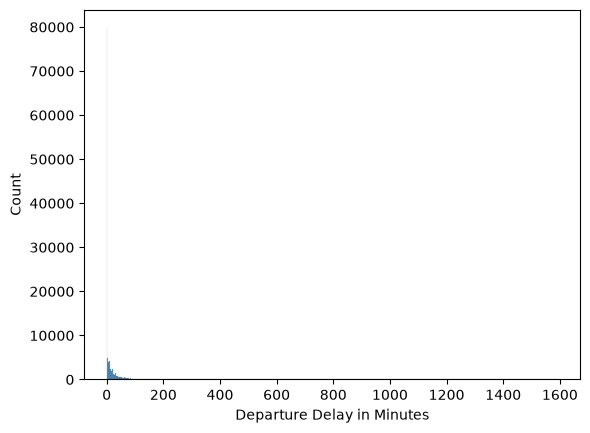

In [29]:
import seaborn as sns

sns.histplot(data=airline, x="Departure Delay in Minutes")

<Axes: xlabel='Gender', ylabel='count'>

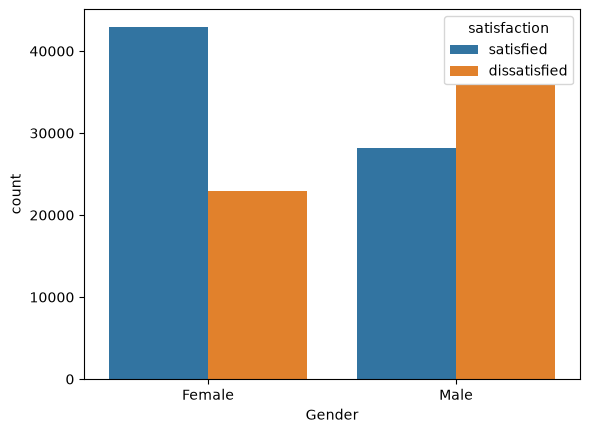

In [ ]:
import seaborn as sns

sns.countplot(data=airline, hue="satisfaction", x="Gender")

In [23]:
# crosstab : 판다스(Pandas)에서 두 개 이상의 열(데이터)을 기준으로
# 빈도수나 통계치를 나타내는 교차표(Cross-tabulation/Contingency Table)를 만드는 함수
pd.crosstab(airline["satisfaction"], airline["Gender"])

Gender,Female,Male
satisfaction,,
dissatisfied,22971,35822
satisfied,42928,28159


In [ ]:
# normalize 속성 :
pd.crosstab(airline["satisfaction"], airline["Gender"], normalize="columns")

Gender,Female,Male
satisfaction,,
dissatisfied,0.348579,0.559885
satisfied,0.651421,0.440115


In [ ]:
cross = pd.crosstab(airline["satisfaction"], airline["Gender"])
from scipy import stats

# 파이제곱검정 사용
stats.chi2_contingency(cross)

Chi2ContingencyResult(statistic=np.float64(5849.476393129708), pvalue=np.float64(0.0), dof=1, expected_freq=array([[29830.61215738, 28962.38784262],
       [36068.38784262, 35018.61215738]]))

<Axes: xlabel='Customer Type', ylabel='count'>

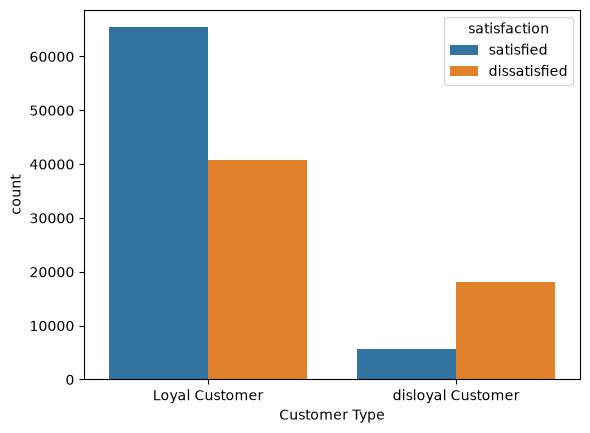

In [24]:
sns.countplot(data=airline, hue="satisfaction", x="Customer Type")

<Axes: xlabel='Type of Travel', ylabel='count'>

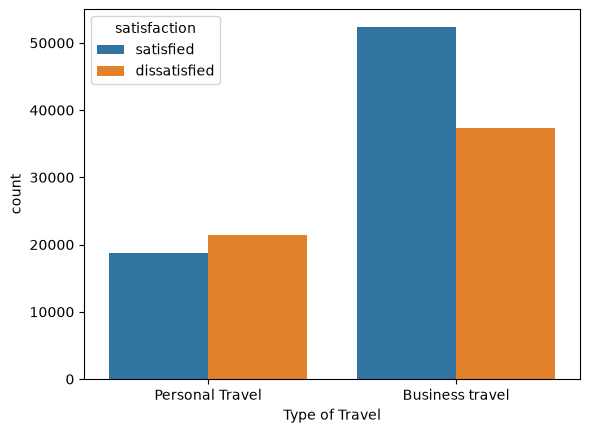

In [25]:
sns.countplot(data=airline, hue="satisfaction", x="Type of Travel")

<Axes: xlabel='Class', ylabel='count'>

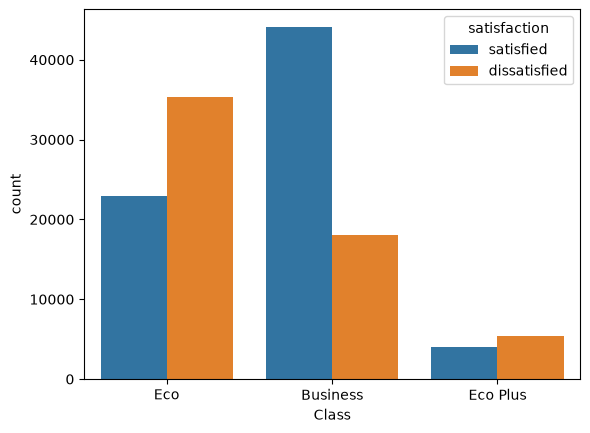

In [26]:
sns.countplot(data=airline, hue="satisfaction", x="Class")

<Axes: xlabel='satisfaction', ylabel='Age'>

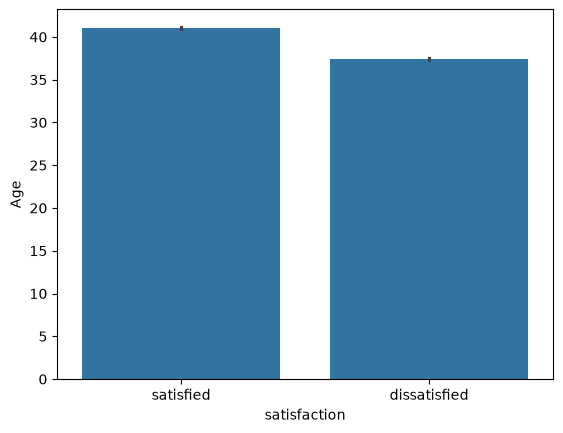

In [33]:
sns.barplot(data=airline, x="satisfaction", y="Age")

<Axes: xlabel='Age', ylabel='Density'>

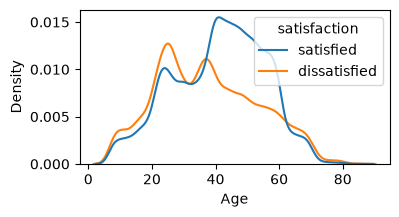

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 2))
sns.kdeplot(data=airline, hue="satisfaction", x="Age")

<Axes: xlabel='Age'>

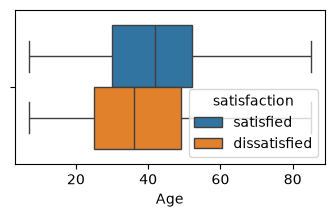

In [43]:
# 나이와 만족도 간의 상관관계 확인

plt.figure(figsize=(4, 2))
sns.boxplot(data=airline, hue="satisfaction", x="Age")

In [36]:
airline.columns

Index(['satisfaction', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
      dtype='str')

<Axes: xlabel='Flight Distance'>

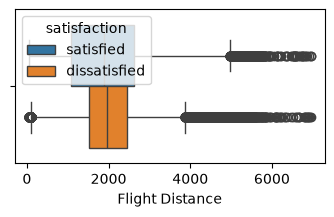

In [44]:
# 비행거리와 만족도 사이의 상관관계 확인

plt.figure(figsize=(4, 2))
sns.boxplot(data=airline, hue="satisfaction", x="Flight Distance")

(0.0, 5000.0)

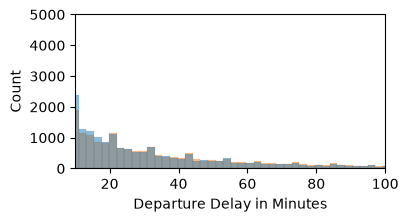

In [49]:
plt.figure(figsize=(4, 2))

# legend 속성
# True : (기본값)자동으로 데이터의 hue, size, style 등을 반영하여 범례를 표시합니다.
# False : 범례를 숨깁니다. (범례를 끄고 싶을 때 가장 자주 사용)
# brief : 데이터가 연속형 변수일 때, 일부 대표적인 값들만 샘플링하여 간단하게 보여줍니다.
# full : 데이터의 모든 고유 값을 범례에 하나씩 다 보여줍니다.
sns.histplot(
    data=airline, hue="satisfaction", x="Departure Delay in Minutes", legend=False
)

# 그래프의 가로축(X축) 표시 범위 : 10 ~ 100
plt.xlim(10, 100)

# 그래프의 세로축(Y축) 표시 범위 : 0 ~ 5000
plt.ylim(0, 5000)

In [47]:
# 출발 지연 시간(분)이 30분보다 작은 경우 No, 30보다 크거나 같을 경우 Yes로
# Delay라는 새로운 컬럼 생성

airline["Delay"] = airline["Departure Delay in Minutes"].apply(
    lambda x: "No" if x <= 30 else "Yes"
)

<Axes: xlabel='Delay', ylabel='count'>

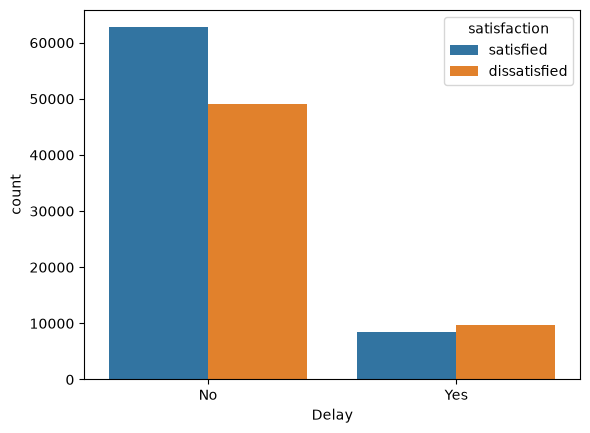

In [ ]:
sns.countplot(data=airline, hue="satisfaction", x="Delay")

### -> 지연이 있는 쪽의 불만족 정도가 지연이 없는 쪽의 정도보다 조금 큰 것을 확인 가능

#### -> 아직은 애매하다고 판단 (다른 지표 추가 확인 필요)


In [50]:
# 점수 독립변수들을 카테고리별로 묶어서 평균점수로 통계내어 독립변수를 변형시키는 방법도 있다.

In [59]:
# 전처리 > encoding, scaling
# encoding : satisfaction(레이블 인코딩 : 종속변수이므로), Gender(원핫 인코딩), Customer Type, Type of Travel, Class
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

# 생성자로 레이블 인코더 생성
lb_enc = LabelEncoder()

# 종속변수 y 레이블 인코딩
target = lb_enc.fit_transform(airline["satisfaction"])

# 생성자로 원핫 인코더 생성
oh_enc = OneHotEncoder(sparse_output=False)

# 독립변수 x 원핫 인코딩
cat_data = oh_enc.fit_transform(
    airline[["Gender", "Customer Type", "Type of Travel", "Class"]]
)

# dt를 복제하여 cat_dt라는 이름의 데이터프레임 생성
cat_df = pd.DataFrame(cat_data, columns=oh_enc.get_feature_names_out())

# airline에서 아래에 적힌 컬럼들을 제거하여 df라는 새 데이터프레임 생성
df = airline.drop(
    ["satisfaction", "Gender", "Customer Type", "Type of Travel", "Class", "Delay"],
    axis=1,
)

# 변수들 복사
features = pd.concat([df, cat_df], axis=1)

# 생성자로 표준 스케일러 생성
scaler = StandardScaler()

# 표준 스케일러로 독립변수들 학습 및 변환
scaled_X = scaler.fit_transform(features)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    scaled_X, target, test_size=0.2, random_state=0
)

In [80]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)
pred_proba = dt_clf.predict_proba(X_test)

In [81]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

print("오차행렬 :")
print(confusion_matrix(y_test, pred))
print(f"정확도 : {accuracy_score(y_test, pred):.4f}")
print(f"정밀도 : {precision_score(y_test, pred):.4f}")
print(f"재현율 : {recall_score(y_test, pred):.4f}")
print(f"F1스코어 : {f1_score(y_test, pred):.4f}")
print(f"ROC_AUC : {roc_auc_score(y_test, pred_proba[:, 1]):.4f}")

오차행렬 :
[[10870   816]
 [  844 13446]]
정확도 : 0.9361
정밀도 : 0.9428
재현율 : 0.9409
F1스코어 : 0.9419
ROC_AUC : 0.9356


In [82]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)
pred = model.predict(X_test)
pred_proba = model.predict_proba(X_test)

print("오차행렬 :")
print(confusion_matrix(y_test, pred))
print(f"정확도 : {accuracy_score(y_test, pred):.4f}")
print(f"F1스코어 : {f1_score(y_test, pred):.4f}")
print(f"ROC_AUC : {roc_auc_score(y_test, pred_proba[:, 1]):.4f}")

오차행렬 :
[[11269   417]
 [  641 13649]]
정확도 : 0.9593
F1스코어 : 0.9627
ROC_AUC : 0.9934


In [83]:
from xgboost import XGBClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)
pred = model.predict(X_test)
pred_proba = model.predict_proba(X_test)

print("오차행렬 :")
print(confusion_matrix(y_test, pred))
print(f"정확도 : {accuracy_score(y_test, pred):.4f}")
print(f"F1스코어 : {f1_score(y_test, pred):.4f}")
print(f"ROC_AUC : {roc_auc_score(y_test, pred_proba[:, 1]):.4f}")

오차행렬 :
[[11269   417]
 [  658 13632]]
정확도 : 0.9586
F1스코어 : 0.9621
ROC_AUC : 0.9933


In [69]:
# 점수 데이터를 평균이나 합산으로 통계내서 변환시키는 작업
# 기준 모델부터 다시 순차적으로 똑같이 진행

In [ ]:
from sklearn.svm import SVC

model = SVC(probability=True)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("오차행렬 :")
print(confusion_matrix(y_test, pred))
print(f"정확도 : {accuracy_score(y_test, pred):.4f}")
print(f"F1스코어 : {f1_score(y_test, pred):.4f}")
print(f"ROC_AUC : {roc_auc_score(y_test, pred_proba[:, 1]):.4f}")

c:\Users\rlawjdgns213\Documents\GitHub\Samsung_Heavy_Industry_AI_Specialist_Education\데이터분석_Advanced\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


# 아이리스 데이터 차원 축소 (PCA) 실습


In [2]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt

iris = load_iris()
columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
irisDF = pd.DataFrame(iris.data, columns=columns)
irisDF["target"] = iris.target

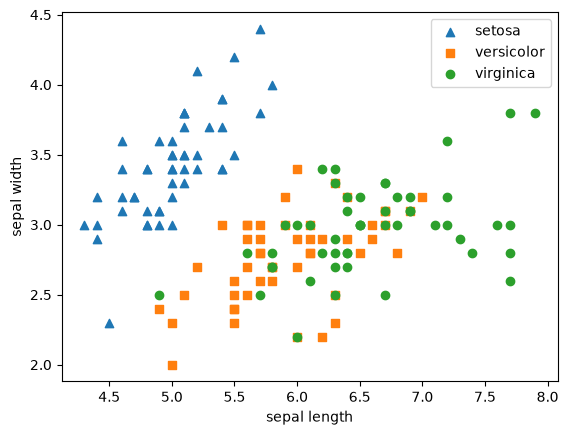

In [3]:
markers = ["^", "s", "o"]
for i, marker in enumerate(markers):
    x_axis_data = irisDF[irisDF["target"] == i]["sepal_length"]
    y_axis_data = irisDF[irisDF["target"] == i]["sepal_width"]
    plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])
plt.legend()
plt.xlabel("sepal length")
plt.ylabel("sepal width")
plt.show()

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
iris_scaled = scaler.fit_transform(irisDF.iloc[:, :-1])


# pca에
pca = PCA(n_components=2)
iris_pca = pca.fit_transform(iris_scaled)
# print(iris_pca)

In [8]:
print(iris_scaled[0])
print(iris_pca[1])

[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
[-2.08096115 -0.67413356]


In [9]:
pca_columns = ["PC1", "PC2"]
irisDF_pca = pd.DataFrame(iris_pca, columns=pca_columns)
irisDF_pca["target"] = iris.target
irisDF_pca.head()

,PC1,PC2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


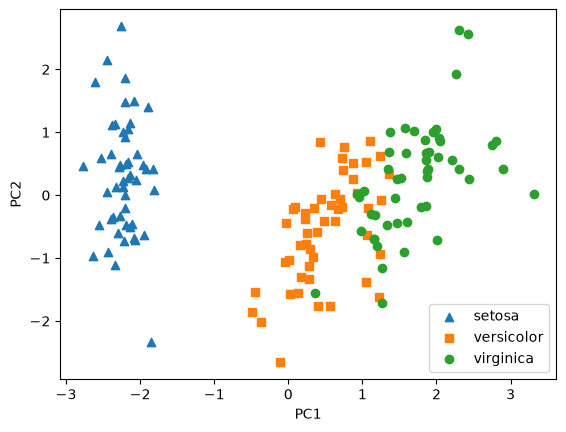

In [ ]:
markers = ["^", "s", "o"]
for i, marker in enumerate(markers):
    x_axis_data = irisDF_pca[irisDF_pca["target"] == i]["PC1"]
    y_axis_data = irisDF_pca[irisDF_pca["target"] == i]["PC2"]
    plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])
plt.legend()
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [12]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762])

In [14]:
pca = PCA(n_components=4)  # 피처 개수만큼
iris_pca = pca.fit_transform(iris_scaled)

In [15]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

- PC1 : 전체의 약 73퍼센트 설명
- PC2 : 전체의 약 23퍼센트 설명
- PC3 : 전체의 약 3퍼센트 설명
- PC4 : 전체의 약 0.5퍼센트 설명

- -> 기본적으로 누적 비율이 80% 이상인 주성분까지 추출
- -> 데이터의 특성을 더 고려하는 경우 90%까지 선택


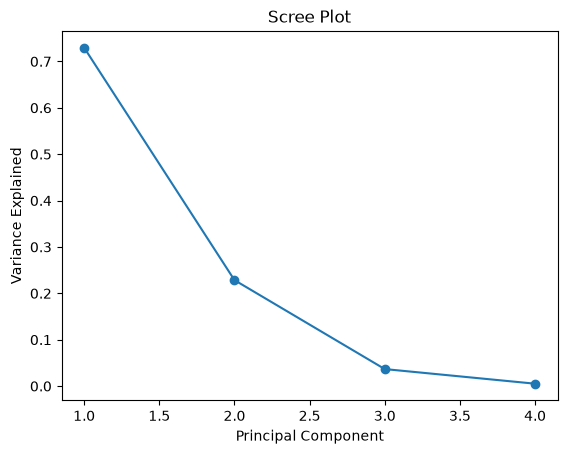

In [13]:
import numpy as np

pca = PCA(n_components=4)  # 피처 개수만큼
pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled)
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, "o-")
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.show()

- 이 경우 PC2 또는 PC3까지 선택할 것 같음.


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rcf = RandomForestClassifier(random_state=156)
# 교차검증 3번
scores = cross_val_score(rcf, iris.data, iris.target, scoring="accuracy", cv=3)
print("원본 데이터 교차 검증 개별 정확도:", scores)
print("원본 데이터 평균 정확도:", np.mean(scores))

원본 데이터 교차 검증 개별 정확도: [0.98 0.94 0.96]
원본 데이터 평균 정확도: 0.96


In [ ]:
pca_X = irisDF_pca[["PC1", "PC2"]]
scores_pca = cross_val_score(rcf, pca_X, iris.target, scoring="accuracy", cv=3)
print("PCA 변환 데이터 교차 검증 개별 정확도:", scores_pca)
print("PCA 변환 데이터 평균 정확도:", np.mean(scores_pca))

PCA 변환 데이터 교차 검증 개별 정확도: [0.88 0.88 0.88]
PCA 변환 데이터 평균 정확도: 0.88


# 아이리스 데이터 LDA 실습


In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

iris = load_iris()
scaler = StandardScaler()
iris_scaled = scaler.fit_transform(iris.data)

lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(iris_scaled, iris.target)
iris_lda = lda.transform(iris_scaled)
print(lda.explained_variance_ratio_)

[0.9912126 0.0087874]


- 특성을 유지하면서 차원 축소를 하기 때문에 점수가 높음


In [ ]:
lda_columns = ["lda1", "lda2"]
irisDF_lda = pd.DataFrame(iris_lda, columns=lda_columns)
irisDF_lda["target"] = iris.target
irisDF_lda.head()

,lda1,lda2,target
0,8.143648,-0.303471,0
1,7.201062,0.794647,0
2,7.565869,0.268079,0
3,6.882372,0.677440,0
4,8.214873,-0.519686,0


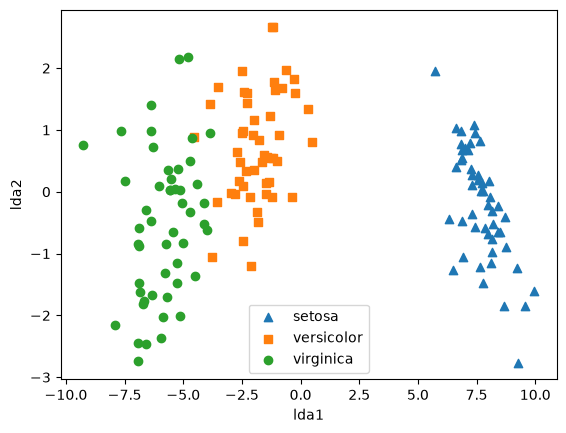

In [ ]:
markers = ["^", "s", "o"]
for i, marker in enumerate(markers):
    x_axis_data = irisDF_lda[irisDF_lda["target"] == i]["lda1"]
    y_axis_data = irisDF_lda[irisDF_lda["target"] == i]["lda2"]
    plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])
plt.legend()
plt.xlabel("lda1")
plt.ylabel("lda2")
plt.show()

In [24]:
# Truncated : 절단된
from sklearn.decomposition import TruncatedSVD

# 남기고자 하는 최종 주성분, 특성(Feature), 또는 차원의 개수는 2개
tsvd = TruncatedSVD(n_components=2)

# 학습
tsvd.fit(iris_scaled)

# 변환
iris_tsvd = tsvd.transform(iris_scaled)
tsvd_columns = ["tsvd1", "tsvd2"]
irisDF_tsvd = pd.DataFrame(iris_tsvd, columns=tsvd_columns)
irisDF_tsvd["target"] = iris.target
irisDF_tsvd.head()

,tsvd1,tsvd2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


In [25]:
tsvd.explained_variance_ratio_

array([0.72962445, 0.22850762])

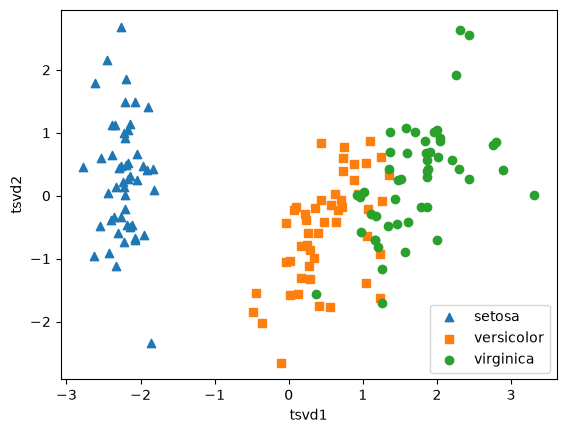

In [ ]:
markers = ["^", "s", "o"]
for i, marker in enumerate(markers):
    x_axis_data = irisDF_tsvd[irisDF_tsvd["target"] == i]["tsvd1"]
    y_axis_data = irisDF_tsvd[irisDF_tsvd["target"] == i]["tsvd2"]
    plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])
plt.legend()
plt.xlabel("tsvd1")
plt.ylabel("tsvd2")
plt.show()

# 아이리스 데이터 NMF 실습


In [ ]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=2)
nmf.fit(iris.data)
iris_nmf = nmf.transform(iris.data)
nmf_columns = ["nmf1", "nmf2"]
irisDF_nmf = pd.DataFrame(iris_nmf, columns=nmf_columns)
irisDF_nmf["target"] = iris.target
irisDF_nmf.head()

c:\Users\rlawjdgns213\Documents\GitHub\Samsung_Heavy_Industry_AI_Specialist_Education\데이터분석_Advanced\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


,nmf1,nmf2,target
0,0.413500,0.104673,0
1,0.365449,0.140978,0
2,0.377800,0.101885,0
3,0.349981,0.148964,0
4,0.415896,0.095306,0


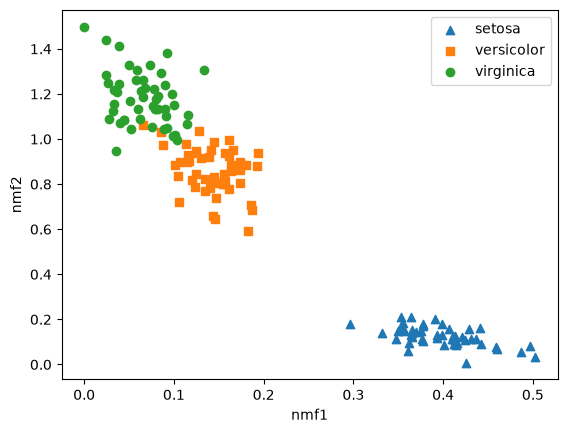

In [ ]:
markers = ["^", "s", "o"]
for i, marker in enumerate(markers):
    x_axis_data = irisDF_nmf[irisDF_nmf["target"] == i]["nmf1"]
    y_axis_data = irisDF_nmf[irisDF_nmf["target"] == i]["nmf2"]
    plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])
plt.legend()
plt.xlabel("nmf1")
plt.ylabel("nmf2")
plt.show()

# 아이리스 데이터 t-SNE 실습


In [29]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=0, perplexity=30)
iris_tsne = tsne.fit_transform(iris_scaled)
tsne_columns = ["tsne1", "tsne2"]
irisDF_tsne = pd.DataFrame(iris_tsne, columns=tsne_columns)
irisDF_tsne["target"] = iris.target

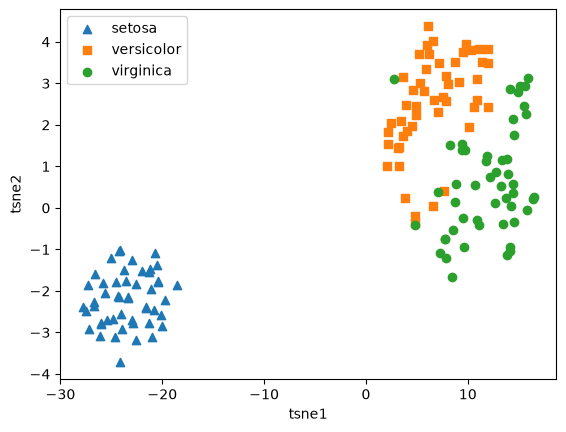

In [ ]:
markers = ["^", "s", "o"]
for i, marker in enumerate(markers):
    x_axis_data = irisDF_tsne[irisDF_tsne["target"] == i]["tsne1"]
    y_axis_data = irisDF_tsne[irisDF_tsne["target"] == i]["tsne2"]
    plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])
plt.legend()
plt.xlabel("tsne1")
plt.ylabel("tsne2")
plt.show()

In [47]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cancer.data)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, cancer.target, test_size=0.2, random_state=0
)

In [48]:
# 로지스틱 회귀분석 모델을 사용하여 차원축소 vs 원본 사용 비교
from sklearn.decomposition import PCA

pca = PCA(n_components=X_scaled.shape[1])

# 학습 및 변환
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

# total_ratio : 총 비율
# 총 비율이 0.85(85%)를 넘어가면 더 이상 주성분 더하지 않음.
# 실행 결과 : 6 (PC1-6까지 더해짐)
total_ratio = 0
for i, ratio in enumerate(pca.explained_variance_ratio_):
    total_ratio += ratio
    if total_ratio >= 0.85:
        print(i + 1)
        break

[4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]
6


In [ ]:
# X_pca[:, :6]

In [54]:
# PCA 적용된 독립변수 학습용, 평가용 데이터
X_train_p, X_test_p = train_test_split(X_pca[:, :6], test_size=0.2, random_state=0)

In [55]:
from sklearn.linear_model import LogisticRegression

# 기본 모델 (PCA 적용 X)
lr_clf = LogisticRegression(random_state=0)
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)


# PCA 적용 버전
lr_clf2 = LogisticRegression(random_state=0)
lr_clf2.fit(X_train_p, y_train)
pred2 = lr_clf2.predict(X_test_p)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

print("< 기본 모델 (PCA 적용 X) >")
print("오차행렬 :")
print(confusion_matrix(y_test, pred))
print(f"정확도 : {accuracy_score(y_test, pred):.4f}")
print(f"정밀도 : {precision_score(y_test, pred):.4f}")
print(f"재현율 : {recall_score(y_test, pred):.4f}")
print(f"F1스코어 : {f1_score(y_test, pred):.4f}")

< 기본 모델 (PCA 적용 X) >
오차행렬 :
[[45  2]
 [ 2 65]]
정확도 : 0.9649
정밀도 : 0.9701
재현율 : 0.9701
F1스코어 : 0.9701


In [56]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

print("< PCA 적용 버전 >")
print("오차행렬 :")
print(confusion_matrix(y_test, pred2))
print(f"정확도 : {accuracy_score(y_test, pred2):.4f}")
print(f"정밀도 : {precision_score(y_test, pred2):.4f}")
print(f"재현율 : {recall_score(y_test, pred2):.4f}")
print(f"F1스코어 : {f1_score(y_test, pred2):.4f}")

< PCA 적용 버전 >
오차행렬 :
[[44  3]
 [ 2 65]]
정확도 : 0.9561
정밀도 : 0.9559
재현율 : 0.9701
F1스코어 : 0.9630


<Axes: >

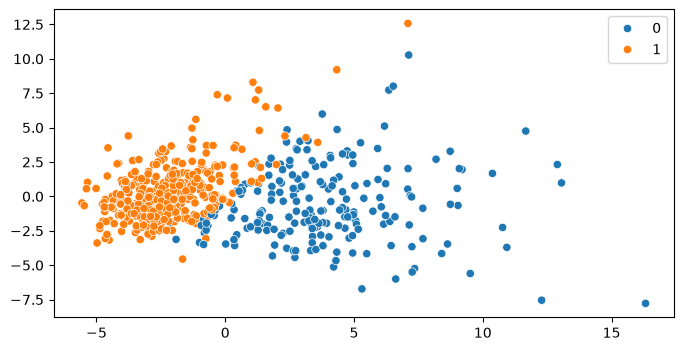

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

X = X_pca[:, :2]
y = cancer.target

plt.figure(figsize=(8, 4))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)

- 모든 분류 데이터는 PCA 사용해서 차원 축소하고 시각화할 수 있음.
- 3차원 데이터는 plotly라는 라이브러리 사용하기
